# Метод опорных векторов Часть 1
Рассмотрим **метод опорных векторов** (support vector machine, SVM).
## SVM с жестким зазором
# Основная идея

Пусть дана задача классификации с единственным признаком $x$ и двумя
классами, которые мы обозначим как $-$ и $+.$ **Решающая граница** (decision
boundary) позволит отнести новый объект к одному из двух классов.


![](https://drive.google.com/uc?export=view&id=1gujKnLW9yiazCEHH01hqUiMUcsmx_mC0)

При этом свободное расположение границы может привести к ошибочной
классификации. В частности, на рисунке ниже новое наблюдение находится
намного ближе к классу $-,$ но классифицируется как $+.$

![](https://drive.google.com/uc?export=view&id=1wZIzbNF7O2dfpfn0YThPlHmMXvB4UVsf)

Очевидно, что тогда граница будет равноудалена от опорных объектов.

Такой алгоритм называется методом классификатора с максимальным
зазором **Текст, выделенный полужирным шрифтом** (maximal margin classifier) или** методом опорных векторов с жестким зазором** (hard-margin SVM), поскольку *не допускает* ошибочной классификации в процессе обучения.

***Примечание.*** О том, зачем позволять алгоритму ошибаться, мы поговорим чуть
ниже.

Несложно заметить, что этот алгоритм подходит для линейно разделимых данных.
Посмотрим, каким образом можно построить решающую границу, а точнее, в
случае SVM, **разделяющую гиперплоскость** (hyperplane).
### Разделяющая гиперплоскость

Рассмотрим набор данных $\mathcal{D} = \{\mathbf{x}_i, y_i\}_{i=1}^N,$ в котором
$ \mathbf x_i \in \mathbb{R}^2 $ и $y \in \{-1, +1\}.$ Построим разделяющую
гиперплоскость $H,$ а также границы коридора (или отрицательные и
положительные гиперплоскости) $H_-$ и $H_+.$

![](https://drive.google.com/uc?export=view&id=1CilEztS74fpGAU9RaSmqdqjlElxpjAwL)

Пусть вектор $\mathbf w$ произвольной длины ортогонален $H.$ Рассмотрим
объект $\mathbf x’$ и попробуем определить, находится ли он по «правую» или по
«левую» сторону от $H.$ Зададим правило

$$ \mathbf w^\top \mathbf x \geq c, $$

согласно которому в зависимости от величины проекции $c$ на вектор $\mathbf w$
мы окажемся на «левой» или «правой» стороне от гиперплоскости $H$ в
направлении $\mathbf w.$ Положим $c =-b.$ Тогда,

* если $\mathbf w^\top \mathbf x + b \geq 0,$ то объект находится «слева» от $H$
и принадлежит к классу $+;$
* если же $\mathbf w^\top \mathbf x + b \lt 0,$ то «справа» от $H$ и принадлежит
к классу $-.$

Таким образом,

$$ H = \{ \mathbf x : \mathbf w^\top \mathbf x + b = 0 \} $$

Введем (произвольное) правило для наблюдений, согласно которому объекты будут
отнесены к классу $+,$ если

$$ \mathbf w^\top \mathbf x_+ + b \geq 1 $$

и к классу $-,$ если

$$ \mathbf w^\top \mathbf x_- + b \leq -1 $$

Если положить $y_i,$ такое что

$$ y_i = \begin{cases} +1 & \quad \text{для класса } +; \\ -1 & \quad \text{для класса }
-, \end{cases} $$

то решающее правило для гиперплоскости можно свести к

$$ y_i \left[ (\mathbf w^\top \mathbf x_i + b) \geq 1 \right] $$

с учетом замены знака неравенства на противоположный при умножении на $y_i =
-1.$

При этом границы коридора задаются через

$$ \begin{split} \begin{array}{ll} H_- = \{ \mathbf x : \mathbf w^\top \mathbf x + b = -1
\} \\ H_+ = \{ \mathbf x : \mathbf w^\top \mathbf x + b = +1 \} \end{array} \end{split} $$

Преобразуем решающее правило

$$ y_i [(\mathbf w^\top \mathbf x_i + b)-1 \geq 0] $$

и введем условие

$$ y_i [(\mathbf w^\top \mathbf x_i + b)-1 = 0] $$

для тех объектов $\mathbf x_i,$ называемых опорными векторами (support
vectors), которые лежат на границах коридора.

### Ширина коридора
Рассмотрим два вектора $\mathbf x_-$ и $\mathbf x_+,$ лежащих на $H_-$ и $H_+$

![](https://drive.google.com/uc?export=view&id=1lYFPsszdi-Blm35BmlVlV7VlvEr9s-BG)

Найдем разницу проекций на $\mathbf w.$

$$ \text{ширина} = \frac{\mathbf{w}}{||\mathbf{w}||} \cdot \mathbf{x}_+-
\frac{\mathbf{w}} {||\mathbf{w}||} \cdot \mathbf{x}_- = \frac{(\mathbf{w} \cdot
\mathbf{x}_+-\mathbf{w} \cdot \mathbf{x}_-)}{||\mathbf{w}||} $$

По условию для объектов, лежащих на $H_-$ и $H_+,$

$$ \begin{split} \begin{array}{rr} \mathbf{w}^\top \mathbf{x}_+ + b &=& 1 \\
\mathbf{w}^\top \mathbf{x}_- + b &=& -1 \end{array} \end{split} $$

Отсюда,

$$ \text{ширина} = \frac{((1-b)-(-1-b))}{||\mathbf{w}||} = \frac{2}{||\mathbf{w}||} $$

### Максимизация зазора
#### Основная задача

Таким образом, основная задача (primal problem) оптимизации сводится к

$$ \max \frac{2}{|| \mathbf w ||} $$

Поскольку константы не влияют на расположение экстремума, то

$$ \max \frac{1}{|| \mathbf w ||} $$

Преобразуем нахождение максимума в поиск минимума

$$ \min || \mathbf w || = \min \frac{1}{2} || \mathbf w ||^2 = \min \frac{1}{2} \mathbf
w^\top \mathbf w $$

с ограничением $y_i [(\mathbf w^\top \mathbf x_i + b)-1 \geq 0] $
Определим функцию Лагранжа

$$ \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2} \mathbf w^\top
\mathbf w-\sum_{i=1}^N \alpha_i [y_i (\mathbf{w}^\top \mathbf{x}_i + b)-1] $$

Поясним, что в данном случае нам необходимо найти минимум относительно
параметров $\mathbf{w}, b$ и максимум относительно $\boldsymbol \alpha =
(\alpha_1, \ldots, \alpha_N),$ то есть седловую точку (saddle point) $\mathcal{L}.$

$$ \min_{\mathbf w, b} \left( \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0}
\mathcal{L}(\mathbf w, b,\boldsymbol \alpha) \right) $$

В самом деле, вначале отдельно рассмотрим задачу максимизации

$$ \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \mathcal{L}(\mathbf w,
b,\boldsymbol \alpha) $$

и найдем такие $\mathbf{w}, b,$ что $y_i (\mathbf w^\top \mathbf x_i + b) \lt 1.$ В этом случае нам не составит труда сделать $\mathcal{L}$ произвольно большой,
подобрав соответствующие значения $\boldsymbol \alpha.$
Предположим, мы подобрали такие $\mathbf w$ и $b,$ что

$$ y_i (\mathbf w^\top \mathbf x_i + b) = 0{,}5 $$

Тогда,

$$ \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2} \mathbf w^\top
\mathbf w-\sum_{i=1}^N \alpha_i (0{,}5-1) = \frac{1}{2} \mathbf w^\top \mathbf w-
\sum_{i=1}^N -0{,}5 \alpha_i $$

Пусть заданы три множителя $\alpha_i,$ и каждый равен единице. В этом случае,

$$ \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2} \mathbf w^\top
\mathbf w-(-1{,}5) = \frac{1}{2} \mathbf w^\top \mathbf w +1{,}5 $$

Если $\alpha_i$ равны двум, то

$$ \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2} \mathbf w^\top
\mathbf w + 3 $$

и так далее. Как следствие, мы можем записать задачу максимизации как

$$ \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \mathcal{L}(\mathbf w,
b,\boldsymbol \alpha) = \begin{cases} \frac{1}{2} \mathbf w^\top \mathbf w &
\text{если } y_i (\mathbf w^\top \mathbf x_i + b) \geq 1; \\ +\infty & \text{если } y_i
(\mathbf w^\top \mathbf x_i + b) \lt 1. \end{cases} $$

Другими словами, максимальное значение $ \max_{\boldsymbol \alpha; \boldsymbol
\alpha \geq 0} \mathcal{L}(\mathbf w, b,\boldsymbol \alpha) $ возможно только при соблюдении изначального условия.

Теперь рассмотрим случай, когда $y_i (\mathbf w^\top \mathbf x_i + b) \geq 1.$
Например,

$$ y_i (\mathbf w^\top \mathbf x_i + b) = 3 $$

$$ \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2} \mathbf w^\top
\mathbf w-\sum_{i=1}^N \alpha_i (3-1) = \frac{1}{2} \mathbf w^\top \mathbf w-
\sum_{i=1}^N 2 \alpha_i $$

В силу того, что $\boldsymbol \alpha; \boldsymbol \alpha \geq 0$ всегда выполняется

$$ -\sum_{i=1}^N 2 \alpha_i \leq 0 $$

Как следствие, при $y_i (\mathbf w^\top \mathbf x_i + b) \geq 1$ функция
$\mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha})$ всегда достигает своего
максимума в точке $\frac{1}{2} \mathbf w^\top \mathbf w.$

$$ \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \mathcal{L}(\mathbf w,
b,\boldsymbol \alpha) = \frac{1}{2} \mathbf w^\top \mathbf w $$

Поскольку изначальной задачей была минимизация $\frac{1}{2} \mathbf w^\top
\mathbf w,$ то

$$ \min_{\mathbf w, b} \frac{1}{2} \mathbf w^\top \mathbf w = \min_{\mathbf w, b}
\left( \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \mathcal{L}(\mathbf w,
b,\boldsymbol \alpha) \right) $$

### Двойственная задача

Найдем и приравняем к нулю частные производные $\mathcal{L}$ относительно
$\mathbf w.$

$$ \begin{gather} \begin{array}{rl} \frac{\partial \mathcal{L}}{\partial \mathbf w}
&=& \mathbf w-\sum_{i=1}^N \alpha_i y_i \mathbf x_i = 0 \\ \mathbf w &=&
\sum_{i=1}^N \alpha_i y_i \mathbf x_i \end{array} \end{gather} $$

Заметим, что вектор параметров $\mathbf w$ представляет собой линейную
комбинацию векторов объектов.

Теперь найдем производные относительно $b.$

$$ \begin{split} \begin{array}{rl} \frac{\partial \mathcal{L}}{\partial b} = -
\sum_{i=1}^N \alpha_i y_i &=& 0 \\ \sum_{i=1}^N \alpha_i y_i &=& 0 \end{array}
\end{split} $$

Подставим найденное значение $\mathbf w$ в $\mathcal{L}.$

$$ \begin{split} \begin{array}{rl} \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha})
=& \frac{1}{2} \mathbf w^\top \mathbf w-\sum_{i=1}^N \alpha_i [y_i (\mathbf{w}^\top
\mathbf{x}_i + b)-1] \\ =& \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j
\mathbf{x}_i^\top \mathbf{x}_j \\ &-\sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i
y_j \mathbf{x}_i^\top \mathbf{x}_j + b \sum_{i=1}^N \alpha_i y_i + \sum_{i=1}^N
\alpha_i \\ =& \sum_{i=1}^N \alpha_i-\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N
\alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top \mathbf{x}_j + b \sum_{i=1}^N \alpha_i y_i
\end{array} \end{split} $$

Поскольку $ \sum_{i=1}^N \alpha_i y_i = 0, $

$$ \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) = \sum_{i=1}^N \alpha_i-\frac{1}
{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top
\mathbf{x}_j $$

Таким образом, мы получили эквивалентную или **двойственную задачу** (dual
problem) оптимизации.

$$ \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \left( \min_{\mathbf w, b}
\mathcal{L} (\mathbf w, b,\alpha_i) \right) $$

При этом опять же,

$$ \min_{\mathbf w, b} \mathcal{L}(\mathbf w,b,\boldsymbol \alpha) = \begin{cases}
\sum_{i=1}^N \alpha_i-\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i
y_j \mathbf{x}_i^\top \mathbf{x}_j & \sum_{i=1}^N \alpha_i y_i = 0 \\ -\infty &
\sum_{i=1}^N \alpha_i y_i \neq 0 \end{cases} $$

Как следствие,

$$ \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \left( \sum_{i=1}^N \alpha_i-
\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top
\mathbf{x}_j \right) $$

$$ \min_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \left( -\sum_{i=1}^N
\alpha_i+\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j
\mathbf{x}_i^\top \mathbf{x}_j \right) $$

с ограничением $ \sum_{i=1}^N \alpha_i y_i = 0. $

### Условия Каруша — Куна — Таккера
Заметим, что основная и двойственная задачи связаны следующим неравенством
(принцип слабой двойственности, weak duality):

$$ d^* = \max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} \min_{\mathbf w, b}
\mathcal{L}(\mathbf w,b,\boldsymbol \alpha) \leq \min_{\mathbf w, b}
\max_{\boldsymbol \alpha; \boldsymbol \alpha \geq 0} = p^* $$

где $d^*$ — оптимальное решение двойственной задачи, а $p^*$ — оптимальное
решение основной задачи.

Неравенство превращается в равенство (принцип сильной двойственности, strong
duality)

$$ d^* = \mathcal{L} (\mathbf w^*, b^*, \boldsymbol \alpha^*) = p^* $$

в случае, если выполняются **условия Каруша — Куна — Таккера** (Karush —
Kuhn — Tucker conditions, KKT), расширяющие метод множителей Лагранжа на
случай ограничений, заданных неравенством. Приведем эти условия.

*Условие стационарност*и (stationary condition)

$$ \frac{\partial \mathcal{L}}{\partial \mathbf w^*} = 0, \quad \frac{\partial
\mathcal{L}}{\partial b^*} = 0 \tag{1} $$

Основное условие осуществимости (primal feasibility condition)

$$ y_i (\mathbf w^{*\top} \mathbf x_i + b^*)-1 \geq 0 \tag{2} $$

Двойственное условие осуществимости (dual feasibility condition)
$$ \alpha_i^* \geq 0 \tag{3} $$

Несложно убедиться, что сформулированная выше задача оптимизации
соответствует каждому из этих условий.

Еще одним условием является условие дополняющей нежесткости (complementary
slackness condition)

$$ \alpha_i^* [y_i (\mathbf w^{*\top} \mathbf x_i + b^*)-1] = 0, \tag{4} $$

которое можно записать и так:

$$ \begin{split} \begin{array}{ll} \alpha_i^* > 0 & \implies & y_i (\mathbf w^{*\top}
\mathbf x_i + b^*)-1 = 0 \\ y_i (\mathbf w^{*\top} \cdot \mathbf x_i + b^*)-1 > 0 &
\implies & \alpha_i^*=0 \end{array} \end{split} $$

Другими словами, если $\alpha_i^* \neq 0,$ то неравенство $ y_i (\mathbf x_i^\top
\mathbf w + b)-1 \geq 0 $ обращается в равенство и $\mathbf x_i$ лежат на $H_-$ и
$H_+.$ Таким образом, параметр $\mathbf w$ зависит лишь от некоторых
(опорных) векторов обучающей выборки.

### Квадратичное программирование
Задача сводится к оптимизации квадратичного функционала

$$ \max_{\boldsymbol \alpha} \left( \sum^N_{i=1} \alpha_i-\frac{1}{2} \boldsymbol
\alpha^\top H \boldsymbol \alpha \right), $$

где $H_{ij} = y_i y_j \mathbf{x}_i^\top \mathbf{x}_j = \mathbf y \mathbf y^\top \odot
\mathbf{x}_i^\top \mathbf{x}_j $ (и $\odot$ означает произведение Адамара) с
ограничениями

$$ \begin{array}{ll} \alpha_i \geq 0 \\ \sum_{i=1}^N \alpha_i y_i = 0 \end{array} $$

Заметим, что поскольку матрица $H$ и накладываемые ограничения
неотрицательно определены (positive semidefinite), то речь идет об оптимизации
выпуклого функционала с единственным решением.

При минимизации, векторизовав $ \sum^N_{i=1} \alpha_i = \mathbf 1^\top
\boldsymbol \alpha $ и $\sum_{i=1}^N \alpha_i y_i = \mathbf y^\top \boldsymbol \alpha,
$ получим

$$ \min_{\boldsymbol \alpha} \left( \frac{1}{2} \boldsymbol \alpha^\top H \boldsymbol
\alpha-\mathbf 1^\top \boldsymbol \alpha \right), $$

$$ \begin{array}{ll} -\boldsymbol \alpha \leq \mathbf 0 \\ \mathbf y^\top \boldsymbol
\alpha = 0 \end{array} $$

### Линейное ядро

Функция $K (\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^\top \mathbf{x}_j$
называется **линейным ядро**м (linear kernel function) алгоритма SVM.

В случае матрицы признаков $X_{n \times d}$ значения ядерной матрицы $K_{n
\times n}$ (kernel matrix), также называемой матрицей Грама (Gram matrix), будут
представлять собой скалярные произведения всех возможных пар $n$ наблюдений
$X.$

В коде линейное ядро можно реализовать следующим образом.

In [ ]:
K = np.zeros((n_samples, n_samples))
  for i in range(n_samples):
    for j in range(n_samples):
      K[i,j] = np.dot(X[i], X[j])

Матрица $H,$ таким образом, будет иметь вид $H_{ij} = \mathbf y \mathbf y^\top
\odot K.$

In [ ]:
H = np.outer(y,y) * K

Одновременно матрицу $H$ можно найти и так

$$ H = (\mathbf y \odot X) \cdot (\mathbf y \odot X)^\top $$

In [ ]:
H = np.dot(y*X, (y*X).T)

с тем неудобством, что вектор y с обычной размерностью `(n,)` придется преобразовывать в `(n,1)`.

### Параметры и прогноз

Параметры $\mathbf w^*$ и $b^*$ можно выразить через

$$ \mathbf w^* = \sum_{s=1}^S \alpha_i y_i \mathbf{x}_i = (\mathbf y \boldsymbol
\alpha)^\top \mathbf x_i $$

$$ b^* = \frac{1}{S} \sum_{i=1}^S ( y_i-\sum_{i=1}^S \alpha_i y_i \mathbf{x}_i^\top
\mathbf{x}_j) = \frac{1}{S} \sum_{i=1}^S \mathbf y-\mathbf w^{*\top} \mathbf x_j $$

При этом опять же учитываются только опорные векторы, для которых $\alpha_i >
0, i = 1, \ldots, S.$

***Примечание.*** Заметим, что параметр $b^*$ можно найти на основе одного
(произвольного) опорного вектора $\mathbf x_s$ и соответствующей метки $y_s$

$$ b^* = y_s-\sum_{i=1}^S \alpha_i y_i \mathbf{x}_i^\top \mathbf{x}_s $$

Среднее арифметическое (или медиана) берутся для обеспечения вычислительной
устойчивости алгоритма.

Правило для классификации нового объекта $\mathbf x’$ можно сформулировать
следующим образом.

$$ \hat{y} = sgn (\mathbf w^{*\top} \mathbf x’ + b^* ) = sgn \left( \sum_{i=1}^S
\alpha_i y_i \mathbf{x}_i^\top \mathbf x’ + b^* \right), $$

где $\hat{y} = \{ -1, +1 \}$ и $sgn$ — сигнум-функция.

### Код на Питоне
## Библиотека CVXOPT

Воспользуемся библиотекой CVXOPT для того, чтобы решить задачу
квадратичного программирования.

$$ \min_x \frac{1}{2} x^\top P x + q^\top x $$

$$ \begin{array}{ll} Gx \preccurlyeq h \\ Ax = b \end{array} $$

Приведем задачу к требуемому **функцией cvxopt.solvers.qp()** формату. В
частности,
**cvxopt.solvers.qp(P, q, G, h, A, b),**
где
* $P$ — матрица $H$ размерностью $n \times n;$
* $q$ — вектор $\mathbf{-1}_{n \times 1};$
* $G$ — диагональная матрица $n \times n$ со значениями $-1$ на главной
диагонали;
* $h$ — нулевой вектор $\mathbf 0_{n \times 1};$
* $A$ — вектор меток $\mathbf y_{n \times 1};$
* $b$ — ноль (скаляр).

Таким образом, поставленная задача полностью совпадает с приведенной выше
задачей минимизации функционала относительно $\boldsymbol \alpha.$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cvxopt
cvxopt.solvers.options['show_progress'] = False
import matplotlib.colors as colors
clrs = ['C0', 'C1']

## Hard-margin SVM
Создадим алгоритм SVM с жестким зазором.


In [5]:
class HardSVM:

  def __init__(self):
    self.support_alphas = None
    self.support_vectors = None
    self.support_vector_labels = None
    self.W = None
    self.intercept = None

  def fit(self, X, y):
    n_samples, n_features = np.shape(X)

    # вычислим ядерную матрицу
    K = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(n_samples):
        K[i,j] = np.dot(X[i], X[j])

    # минимизируем квадратичный функционал
    P = cvxopt.matrix(np.outer(y,y) * K)
    q = cvxopt.matrix(np.ones(n_samples) * -1)
    # tc='d' переводит даннные в числа с плавающей точкой
    A = cvxopt.matrix(y, (1, n_samples), tc='d')
    b = cvxopt.matrix(0.0)
    G = cvxopt.matrix(np.identity(n_samples) * -1)
    h = cvxopt.matrix(np.zeros(n_samples))

    solution = cvxopt.solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(solution['x'])

    # найдем ненулевые множители Лагранжа,
    idx = alphas > 1e-5
    self.support_alphas = alphas[idx]
    # опорные векторы и соответствующие метки
    self.support_vectors = X[idx]
    self.support_vector_labels = y[idx]

    self.W = np.dot((self.support_vector_labels * self.support_alphas).T, self.support_vectors)
    self.intercept = np.mean(self.support_vector_labels - np.dot(self.support_vectors, self.W))

    return self

  def predict(self, X):

    return np.sign(np.dot(X, self.W) + self.intercept)

### Линейно разделимые данные
Подготовим набор линейно разделимых данных.

In [6]:
def get_separable_data():
  X_train = np.array([[-3.5, -1],[-3, 0], [-3, 1], [-2.7, -1.3], [-2, -1], [-2, -2.7],
                      [-1, -2.5], [0, -3], [0, 1], [0, 2.5], [1, 2], [0.7, 3.8],
                      [2.1, 0.2], [2.3, 1], [2.8, 1.8], [2.2, 2.8]])
  y_train = np.array([-1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[0, 0], [1, -3]])
  y_test = np.array([1, -1])

  return X_train, y_train, X_test, y_test

### Уравнение решающей границы

Кроме этого, создадим функцию, которая будет выводить данные, а также
решающую границу $H$ и границы коридора $H_-$ и $H_+.$

Для двух признаков $x_1$ и $x_2$ получим

$$ \mathbf w^\top \mathbf x_i + b = 0 \quad \implies \quad \begin{bmatrix} w_1 & w_2
\end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + b = 0 $$

$$ w_1 x_1 + w_2 x_2 + b = 0 $$

$$ w_2 x_2 = -w_1x_1-b $$

$$ x_2 = -\frac{w_1}{w_2} x_1-\frac{b}{w_2}, $$

где $-\frac{w_1}{w_2}$ — наклон, а $-\frac{b}{w_2}$ — сдвиг $H.$ Кроме этого,
мы знаем, что половина ширины коридора (margin) равна

$$ \text{margin} = \frac{1}{|| \mathbf w ||} $$

При этом, поскольку $\mathbf w$ ортогонален $H,$ то для нахождения $H_-$ и
$H_+$ необходимо нормализовать $\mathbf w,$

$$ \hat{\mathbf w} = \frac{\mathbf w}{||\mathbf w||}, $$

а затем сдвинуть $H$ вверх и вниз на $\text{margin} \cdot \hat{\mathbf w} $
$$ H_- = H-\text{margin} \cdot \hat{\mathbf w} $$

$$ H_+ = H + \text{margin} \cdot \hat{\mathbf w} $$

Объявим функцию plot_data().

In [7]:
def plot_data(X, y, title, w=None, b=None):
  plt.figure(figsize=(5, 5))
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
              cmap=colors.ListedColormap(clrs))

  x_min, x_max, y_min, y_max = -4, 4, -4, 4
  xx = np.linspace(x_min, x_max)

  hyperplane_slope = -w[0]/w[1]
  hyperplane_intercept = -b/w[1]
  yy = hyperplane_slope*xx + hyperplane_intercept
  margin = 1 / np.sqrt(np.sum(w**2))
  w_hat = w / np.linalg.norm(w)
  hyperplane = np.array(list(zip(xx, yy)))
  hyperplane_plus = hyperplane + margin * w_hat
  hyperplane_minus = hyperplane - margin * w_hat

  plt.plot(hyperplane[:, 0], hyperplane[:, 1], 'k-')
  plt.plot(hyperplane_plus[:, 0], hyperplane_plus[:, 1], 'g--')
  plt.plot(hyperplane_minus[:, 0], hyperplane_minus[:, 1], 'g--')

  plt.xlim(x_min, x_max)
  plt.ylim(y_min, y_max)
  plt.title(title)
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.show()

### Обучение и прогноз модели
Создадим датасеты.

In [8]:
X_train, y_train, X_test, y_test = get_separable_data()
X_train.shape, y_train.shape

((16, 2), (16,))

Обучим модель и сделаем прогноз.

In [9]:
hard_svm = HardSVM()
hard_svm.fit(X_train, y_train).predict(X_test)

array([ 1., -1.])

Выведем опорные векторы.

In [10]:
hard_svm.support_vectors

array([[-3.,  1.],
       [ 0., -3.],
       [ 0.,  1.]])

Посмотрим на данные и гиперплоскость.

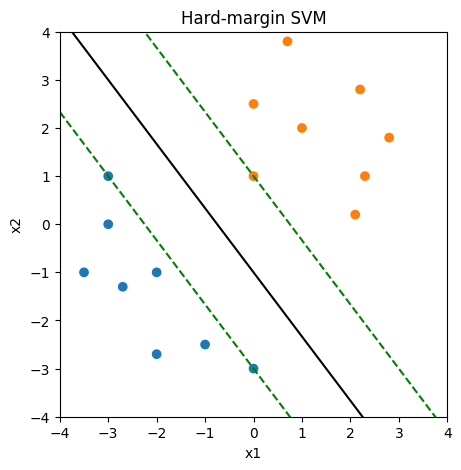

In [11]:
plot_data(X_train, y_train, title='Hard-margin SVM',
          w=hard_svm.W, b=hard_svm.intercept)

# Метод опорных векторов. Часть 2
## SVM с мягким зазором
### Основная идея

Вернемся к примеру с единственным признаком, однако теперь представим, что в
данных присутствуют выбросы и из-за этого они **линейно неразделимы**
(linearly non-separable).

![](https://drive.google.com/uc?export=view&id=1tesFEwds_3QqT-xauCVAgd1ml6KeuqOl)

При этом если позволить алгоритму ошибиться с классификацией одного
наблюдения, мы получим модель, которая (возможно) будет хорошо предсказывать
новые данные.

![](https://drive.google.com/uc?export=view&id=1RT08Hcwokr8qbyR_6l-Zmnb6yLxdc7fl)

Такой алгоритм называется методом опорных векторов с мягким
зазором **Текст, выделенный полужирным шрифтом** (soft-margin SVM).

Допуская большее или меньшее количество ошибочно классифицируемых
наблюдений мы можем либо увеличивать точность алгоритма на обучающей
выборке, либо повышать его обобщающую способность.

Можно сказать, что таким образом обеспечивается компромисс между смещением
и разбросом (bias-variance tradeoff).

## Оценка ошибочной классификации

Для того чтобы обучить такой алгоритм для каждого наблюдения введем
переменные $\xi_i, $ где $i = 1, \ldots, n$ (slack variable)

$$ \xi_i = 1-y_i(\mathbf w^\top \mathbf x_i + b), \quad \xi_i \geq 0, $$

которые показывают, насколько алгоритм ошибся при классификации объекта.

![](https://drive.google.com/uc?export=view&id=1yc1-RsV_UTXNeDR5mC1qo_P4k7m0wjGY)

На схеме выше для положительных объектов:

* если наблюдение находится на «своей» стороне или непосредственно на
«своем» зазоре $H_+,$ то $\xi,$ и, в частности, $\xi_1$ и $\xi_4$ равны нулю;
* если объект находится между $H$ и $H_+,$ то, например, $0 < \xi_3 < 1;$
* если наблюдение оказывается на «неправильной» стороне, то $\xi_2 > 1.$

Аналогичное рассуждение можно провести и для отрицательных объектов.

Таким образом, просуммировав все $\xi_i$ мы получим оценку того, какое
количество объектов было классифицировано неправильно $\xi_i > 1$ или не
идеально $0 < \xi_i < 1.$

Это количество нам бы хотелось минимизировать.

## Задача оптимизации
### Основная задача
Сформулируем основную задачу оптимизации.

$$ \begin{gather} \min_{\mathbf w,\mathbf b, \xi}\; \left( \frac{1}{2}||\mathbf w||^2 + C
\sum_{i=1}^n \xi_i \right) \\ y_i \left(\mathbf w^\top \mathbf x_i + b \right) \geq 1-\xi_i,
\quad \xi_i \geq 0 \end{gather} $$

Обратим внимание на два момента:
* во-первых, $1-\xi_i$ будет меньше единицы только в том случае, если
классификатор ошибается (а также допускает объекты между
гиперплоскостью и «своим» зазором);
* кроме того, гиперпараметр $C$ определяет значимость такой ошибки, $C
\xi_i:$
  * если $C$ невелико, например, $C=0{,}1,$ то количество ошибочно
классифицированных объектов может быть довольно большим (широкий
коридор);
  * если наоборот велико, $C=100,$ то алгоритм постарается не допускать
ошибочной классификации (узкий коридор);
  * при $C=\infty$ получается метод опорных векторов с жестким зазором.

***Примечание.*** Слагаемое $C \sum_{i=1}^n \xi_i$ можно считать L1-регуляризатором функции потерь.
### Двойственная задача
Введем **функцию Лагранжа**.

$$ \begin{gather} \begin{array}{rl} \mathcal{L} (\mathbf w, b, \boldsymbol \xi,
\boldsymbol \alpha, \boldsymbol \beta) =& \frac{1}{2} \mathbf w^\top \mathbf w + C
\sum_{i=1}^N \xi_i \\ &-\sum^N_{i=1} \alpha_i[y_i(\mathbf w^\top \mathbf x_i +
b)-1+\xi_i]-\sum^N_{i=1} \beta_i \xi_i \;, \end{array} \end{gather} $$

где $\boldsymbol \alpha, \boldsymbol \beta$ — множители Лагранжа, и поставим
задачу ее максимизации

$$ \max_{\boldsymbol \alpha, \boldsymbol \beta : \boldsymbol \alpha \geq 0,
\boldsymbol \beta \geq 0} \mathcal{L} (\mathbf w, b, \boldsymbol \xi, \boldsymbol
\alpha, \boldsymbol \beta) $$

Найдем производные относительно $\mathbf w, b, \boldsymbol \xi$ и приравняем их
к нулю.

$$ \begin{gather} \begin{array}{rl} \frac{\partial \mathcal{L}}{\partial \mathbf w}
&=& \mathbf w-\sum_{i=1}^N \alpha_i y_i \mathbf x_i = 0 \\ \mathbf w &=&
\sum_{i=1}^N \alpha_i y_i \mathbf x_i \end{array} \end{gather} $$

$$ \begin{split} \begin{array}{rl} \frac{\partial \mathcal{L}}{\partial b} = -
\sum_{i=1}^N \alpha_i y_i &=& 0 \\ \sum_{i=1}^N \alpha_i y_i &=& 0 \end{array}
\end{split} $$

$$ \begin{split} \begin{array}{cc} \frac{\partial \mathcal{L}}{\partial \boldsymbol \xi}
= C-\alpha_i-\beta_i = 0 \\ \beta_i = C-\alpha_i \end{array} \end{split} $$

Выразим ограничения для множителей $\alpha_i, \beta_i$ через ограничение для
$\alpha_i.$

$$ \begin{split} \begin{array}{cc} \beta_i \geq 0 \implies C-\alpha_i \geq 0 \implies
\alpha_i \leq C \\ \alpha_i \geq 0, \alpha_i \leq C \implies 0 \leq \alpha_i \leq C
\end{array} \end{split} $$

Подставив полученные значения обратно в $\mathcal{L}$ и преобразав выражение,
получим

$$ \begin{gather} \begin{array}{rl} \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha})
&=& \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j
\mathbf{x}_i^\top \mathbf{x}_j + C \sum_{i=1}^N \xi_i \\ && + \sum_{i=1}^N
\alpha_i-\sum_{i=1}^N \alpha_i \xi_i \\ &&-\sum_{i=1}^N \sum_{j=1}^N \alpha_i
\alpha_j y_i y_j \mathbf{x}_i^\top \mathbf{x}_j-b \sum_{i=1}^N \alpha_i y_i \\ &&-C
\sum_{i=1}^N \xi_i + \sum_{i=1}^N \alpha_i \xi_i \\ &=& \sum_{i=1}^N \alpha_i-
\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top
\mathbf{x}_j \end{array} \end{gather} $$

$$ \max_{\boldsymbol \alpha} \mathcal{L} (\mathbf{w}, b, \boldsymbol{\alpha}) $$

с ограничениями $ \sum_{i=1}^N \alpha_i y_i = 0 $ и $ 0 \leq \alpha_i \leq C. $

Отдельно рассмотрим **условия дополняющей нежесткости**.

$$ \begin{gather} \begin{array}{rrl} \alpha_i^* [ y_i (\mathbf w^{*\top} \mathbf x_i +
b^*)-1+\xi_i^* ] &=& 0 \\ \beta_i^* \xi_i^* &=& 0 \end{array} \end{gather} $$

Исходя из первого условия, если $\alpha_i^* \gt 0, $ то для того, чтобы
произведение было равно нулю, $y_i (\mathbf w^{*\top} \mathbf x_i +
b^*)-1+\xi_i^*$ должно быть равно нулю. Как следствие, так как $\xi_i^* \geq 0,$

$$ y_i (\mathbf w^{*\top} \mathbf x_i + b^*)-1 \leq 0 $$

Одновременно, если $\beta_i^* \gt 0$ или, что то же самое, $ \alpha_i^* \lt C, $ в
силу $\alpha_i^* + \beta_i^* = C,$ то $\xi_i^* = 0$ и, поскольку по основному
условию осуществимости $y_i (\mathbf w^{*\top} \mathbf x_i + b^*) \geq 1-\xi_i^*,$
получаем

$$ y_i (\mathbf w^{*\top} \mathbf x_i + b^*)-1 \geq 0 $$

Таким образом,

$$ \begin{split} \begin{array}{ll} \alpha_i^* < C &\implies & y_i (\mathbf w^{*\top}
\mathbf x_i + b^*)-1 \geq 0 \\ \alpha_i^* \gt 0 &\implies& y_i (\mathbf w^{*\top}
\mathbf x_i + b^*)-1 \leq 0 \end{array} \end{split} $$

Или, что то же самое,

$$ \begin{split} \begin{array}{ll} \alpha_i^* = 0 & \implies & y_i (\mathbf w^{*\top}
\mathbf x_i + b^*)-1 \geq 0 \\ 0 \lt \alpha_i^* \lt C & \implies & y_i (\mathbf w^{*\top}
\mathbf x_i + b^*)-1 = 0 \\ \alpha_i^* = C & \implies & y_i (\mathbf w^{*\top} \mathbf
x_i + b^*)-1 \leq 0 \end{array} \end{split} $$

Другими словами, в методе опорных векторов с мягким зазором наблюдения с
$\alpha_i^* \neq 0$ будут включать как опорные объекты, так и ошибочно
классифицированные наблюдения, для которых $\xi_i > 0.$

Таким образом, задача сводится к **минимизации** (выпуклого) квадратичного
функционала

$$ \min_{\boldsymbol \alpha} \left( \frac{1}{2} \boldsymbol \alpha^\top H \boldsymbol
\alpha-\mathbf 1^\top \boldsymbol \alpha \right) $$

с ограничениями

$$ \begin{array}{ll} \mathbf 0 \leq -\boldsymbol \alpha \leq \mathbf C \\ \mathbf y^\top
\boldsymbol \alpha = 0, \end{array} $$

где единственным отличием от метода опорных векторов с жестким зазором будет
дополнительное ограничение $-\boldsymbol \alpha \leq \mathbf C.$

## Код на Питоне
### Библиотека CVXOPT
С точки зрения формата библиотеки CVXOPT нам необходимо внести измерения в
матрицу $G$ и вектор $h.$ Новая матрица $G_{2n \times n}$ будет состоять из двух
вертикально соединенных диагональных матриц размерности $n \times n $ со
значениями $-1$ и $1$ на главных диагоналях соответственно.

К вектору $h_{2n \times 1}$ мы добавим $n$ значений $C.$ Для $n=2$ $G$ и $h$
примут вид

$$ G = \begin{bmatrix} -1 & 0 \\ 0 & -1 \\ 1 & 0 \\ 0 & 1\end{bmatrix}, \quad h =
\begin{bmatrix} 0 \\ 0 \\ C \\ C \end{bmatrix} $$

### Класс SoftSVM

## Soft-margin SVM

In [12]:
class SoftSVM:

  def __init__(self, C=None):
    self.support_alphas = None
    self.support_vectors = None
    self.support_vector_labels = None
    self.W = None
    self.intercept = None
    self.C = C

  def fit(self, X, y):
    n_samples, n_features = np.shape(X)

    K = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(n_samples):
        K[i,j] = np.dot(X[i], X[j])

    P = cvxopt.matrix(np.outer(y,y) * K)
    q = cvxopt.matrix(np.ones(n_samples) * -1)
    A = cvxopt.matrix(y, (1, n_samples), tc='d')
    b = cvxopt.matrix(0.0)

    if not self.C:
      G = cvxopt.matrix(np.identity(n_samples) * -1)
      h = cvxopt.matrix(np.zeros(n_samples))
    else:
      G_max = np.identity(n_samples) * -1
      G_min = np.identity(n_samples)
      G = cvxopt.matrix(np.vstack((G_max, G_min)))
      h_max = cvxopt.matrix(np.zeros(n_samples))
      h_min = cvxopt.matrix(np.ones(n_samples) * self.C)
      h = cvxopt.matrix(np.vstack((h_max, h_min)))

    solution = cvxopt.solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(solution['x'])

    idx = alphas > 1e-5
    self.support_alphas = alphas[idx]
    self.support_vectors = X[idx]
    self.support_vector_labels = y[idx]

    self.W = np.dot((self.support_vector_labels * self.support_alphas).T, self.support_vectors)
    self.intercept = np.mean(self.support_vector_labels - np.dot(self.support_vectors, self.W))

    return self

  def predict(self, X):

    return np.sign(np.dot(X, self.W) + self.intercept)

### Линейно неразделимые данные
Изменим класс *одного* наблюдения в данных, чтобы сделать их линейно
неразделимыми.

In [13]:
def get_non_separable_data():
  X_train = np.array([[-3.5, -1], [-3, 0], [-3, 1], [-2.7, -1.3], [-2, -1], [-2, -2.7],
                  [-1, -2.5], [0, -3], [0, 1], [0, 2.5], [1, 2], [0.7, 3.8],
                  [2.1, 0.2], [2.3, 1], [2.8, 1.8], [2.2, 2.8]])
  y_train = np.array([-1, -1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[0, 0], [1, -3]])
  y_test = np.array([1, -1])

  return X_train, y_train, X_test, y_test

Создадим обучающую выборку.

In [14]:
X_train, y_train, _, _ = get_non_separable_data()

### Обучение модели
Вначале обучим модель с параметром $C=0{,}1.$

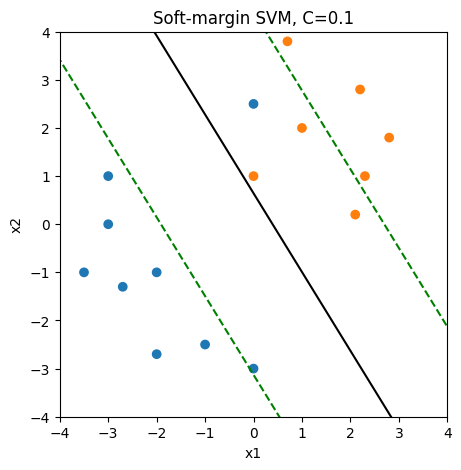

In [15]:
soft_svm = SoftSVM(C=0.1).fit(X_train, y_train)
plot_data(X_train, y_train, title='Soft-margin SVM, C=0.1',
          w=soft_svm.W, b=soft_svm.intercept)

Теперь изменим параметр на $C=100.$

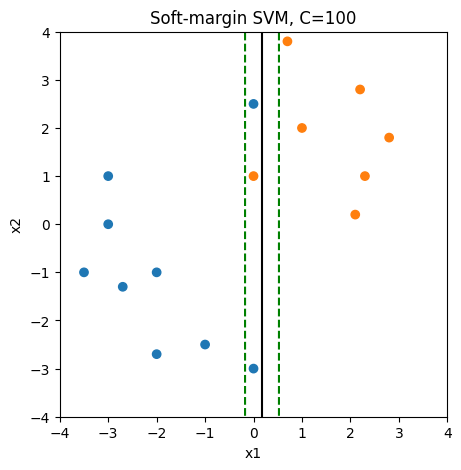

In [16]:
soft_svm = SoftSVM(C=100).fit(X_train, y_train)
plot_data(X_train, y_train, title='Soft-margin SVM, C=100',
          w=soft_svm.W, b=soft_svm.intercept)

Ожидаемо, с ростом значимости слагаемого регуляризации алгоритм старается не
допустить ошибочной классификации.

# SVM и метод градиентного спуска
## Hinge loss

Обратим внимание, что данное выше определение $\xi_i$

$$ \xi_i = 1-y_i(\mathbf w^\top \mathbf x_i + b), \quad \xi_i \geq 0 $$

можно записать и так

$$ \xi_i = \max \left( \left( 1-y_i (\mathbf w^\top \mathbf x_i + b) \right), 0 \right), $$

т.е. представить в виде функции hinge loss

![](https://drive.google.com/uc?export=view&id=1mwcWCNIFKxiGiWWAzvZq3KHCzCWKJrXL)

Тогда общую функцию потерь можно записать как

$$ \min_{\mathbf w, b} \left( \frac{1}{N} \sum_{i=1}^N \underbrace{
\vphantom{\frac{1}{1}} \max \left( \left( 1-y_i (\mathbf w^\top \mathbf x_i + b) \right),
0 \right) }_{\text{hinge loss}} + \underbrace{\frac{\lambda}{2}||\mathbf
w||^2}_{\text{regularizer}} \right), $$

где, по сравнению с решаемой через квадратичное программирование задачей, мы
поменяли местами слагаемые и теперь:
* hinge loss является основной функцией потерь; а
* слагаемое $||\mathbf w||^2$ — L2 регуляризатор с коэффициентом
$\frac{\lambda}{2}.$
### Субградиентный спуск
Найдем градиент функции hinge loss. Вначале для удобства внесем коэффициент
$b$ в вектор параметров $\mathbf w,$ добавив в данные столбец из единиц.

Теперь разложим функцию потерь $J(\mathbf w)$ на два возможных сценария.

$$ \begin{cases} J(\mathbf w) = \frac{\lambda}{2} || \mathbf w ||^2 & \text{если } \; y_i
(\mathbf w^\top \mathbf x_i) \geq 1 \\ J(\mathbf w) = \frac{\lambda}{2} || \mathbf w ||^2
+ 1-y_i(\mathbf w^\top \mathbf x_i) & \text{если } \; y_i (\mathbf w^\top \mathbf x_i) \lt
1 \end{cases} $$

***Примечание.*** Поскольку в точке $ y_i (\mathbf w^\top \mathbf x_i) = 1 $ градиент не
определен, используем один из возможных субградиентов.

Найдем (суб)градиент для каждого из сценариев.

$$ \begin{cases} \frac{\partial J}{\partial \mathbf w} = \lambda \mathbf w \\
\frac{\partial J}{\partial \mathbf w} = \lambda \mathbf w-y_i \mathbf x_i \end{cases} $$

При этом гиперпараметры $\lambda$ и $C$ связаны следующим отношением

$$ C = \frac{1}{\lambda N} \quad \implies \quad \lambda = \frac{1}{CN} $$

## Код на Питоне
Приведем код на Питоне. Будем использовать стохастический градиентный спуск,
то есть обновлять веса на основе одного объекта.

## Gradient SVM

In [17]:
class GradientSVM:

  def __init__(self, learning_rate=1e-3, lambda_param=1e-2, epochs=100000):
    self.lr = learning_rate
    self.lambda_param = lambda_param
    self.epochs = epochs
    self.W = None
    self.loss_history = []

  def _compute_hinge_loss(self, x, y, idx):

    return max(0, 1-(y[idx] * np.dot(x, self.W)))

  def _compute_gradients(self, x, y, idx):
    # найдем градиенты для каждого сценария
    if (y[idx] * (np.dot(x, self.W))) >= 1:
      dw = self.lambda_param * self.W
    else:
      dw = self.lambda_param * self.W - y[idx] * x

    return dw

  def fit(self, X, y):
    # добавим столбец из единиц
    X = np.c_[np.ones((len(X), 1)), X]
    # инициализируем веса с учетом дополнительного признака
    self.W = np.zeros(X.shape[1])

    # на каждой эпохе
    for _ in range(self.epochs):
      loss = 0
      # для каждого объекта
      for idx, x in enumerate(X):
        # рассчитаем и учтем уровень ошибки
        loss += self._compute_hinge_loss(x, y, idx)
        # найдем градиент
        dw = self._compute_gradients(x, y, idx)
        # обновим веса
        self.W -= self.lr * dw
      # для каждой эпохи рассчитаем и
      # запишем средний уровень ошибки
      self.loss_history.append(loss/len(X))

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]

    return np.sign(np.dot(X, self.W))

Вначале обучим алгоритм с параметром $C=0{,}1$ или $\lambda = \frac{1}{0{,}1
\cdot 16} = 0{,}625.$

In [18]:
X_train, y_train, X_test, y_test = get_non_separable_data()

In [19]:
C1=.1
lambda1 = 1/(C1 * X_train.shape[0])
grad_svm = GradientSVM(lambda_param=lambda1).fit(X_train, y_train)

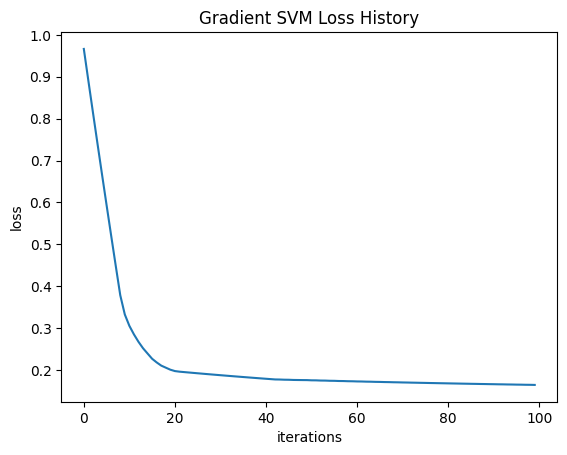

In [21]:
plt.plot(grad_svm.loss_history[:100])
plt.title('Gradient SVM Loss History')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()

Посмотрим на гиперплоскость.

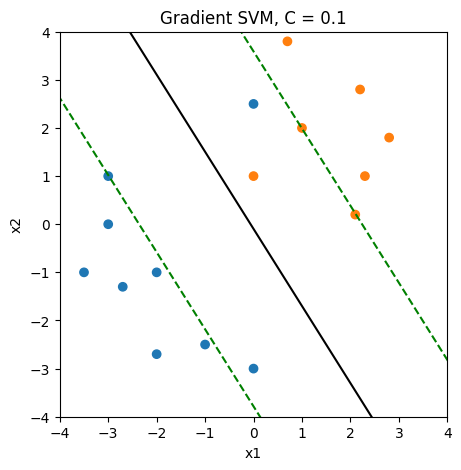

In [20]:
plot_data(X_train, y_train, title='Gradient SVM, C = 0.1',
          w=grad_svm.W[1:], b=grad_svm.W[0])

Теперь обучим модель с параметром $C=100$ или $\lambda = \frac{1}{100 \cdot 16}
= 0{,}000625.$

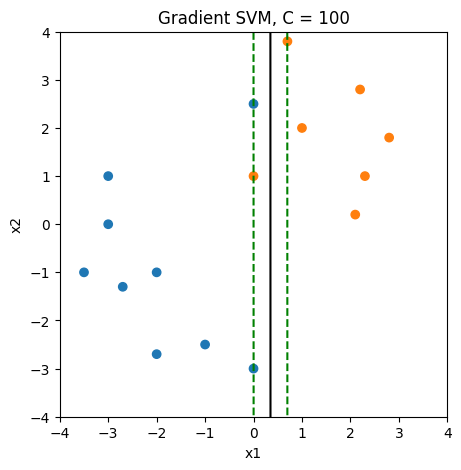

In [22]:
C2 = 100
lambda2 = 1/(C2 * X_train.shape[0])
grad_svm2 = GradientSVM(lambda_param=lambda2).fit(X_train, y_train)
plot_data(X_train, y_train, title='Gradient SVM, C = 100',
          w=grad_svm2.W[1:], b=grad_svm2.W[0])

Примечания:

* в библиотеке Sklearn классификатор SVM с оптимизацией методом
градиентного спуска реализован в классе SGDClassifier (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) с параметром loss =
‘hinge’;
* для оптимизации SVM методом субградиентного спуска с уменьшающимся
размером шага предложен алгоритм Pegasos (https://home.ttic.edu/~nati/Publications/PegasosMPB.pdf).

# Метод опорных векторов. Часть 3
## Kernel SVM
## Ядро SVM
### Сходство наблюдений

Вспомним, что задача SVM сводится к максимизации ширины коридора между
наблюдениями через максимизацию двойственной функции

$$ \max_{\boldsymbol{\alpha}} \mathcal{L} (\boldsymbol{\alpha}) =
\max_{\boldsymbol{\alpha}} \left( \sum_{i=1}^N \alpha_i-\frac{1}{2} \sum_{i=1}^N
\sum_{j=1}^N \alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top \mathbf{x}_j \right), $$

Будем учитывать только те векторы, для которых $\alpha_i > 0.$ Посмотрим на
скалярное произведение с точки зрения сходства двух нормализованных векторов
$\mathbf x_i$ и $\mathbf x_j.$

$$ \cos \theta = \frac{\mathbf x_i \cdot \mathbf x_j}{|| \mathbf x_i || || \mathbf x_j || } $$

В случае если векторы **не схожи**, их скалярное произведение близко к нулю, а
значит второе слагаемое будет незначительно влиять на $\mathcal{L}.$

![](https://drive.google.com/uc?export=view&id=11T_48KGH-3v1Vvl0qaAm_LQzcjYrregp)

Если же векторы **схожи** и их скалярное произведение близко к единице, то
возможны два варианта:
* *первай вариант:* объекты принадлежат к одному классу, например, для
обоих $y_i = +1$ или $y_i = -1;$ в этом случае их скалярное произведение
будет положительным, а значит второе слагаемое в $\mathcal{L}$ будет
вычитаться из первого и уменьшать целевую функцию, при оптимизации
алгоритм будет отдавать меньшее предпочтение таким парам объектов;
* *второй вариант:* объекты принадлежат к разным классам и их скалярное
произведение всегда отрицательно; второе слагаемое прибавляется к первому
и эти пары объектов способствуют максимизации $\mathcal{L}$ и, как
следствие, ширины коридора между объектами.

![](https://drive.google.com/uc?export=view&id=1nP3_aBTSDty9PCW044Pdka04vztB-b3Q)



## Спрямление пространства

Рассмотрим данные с нелинейной разделяющей поверхностью в исходном
пространстве признаков $\mathcal{L}$ (несложно увидеть, что где бы мы ни
расположили *линейную* границу, количество ошибочно классифицированных
объектов было бы слишком велико).
![](https://drive.google.com/uc?export=view&id=1zuI9y8Jn8wsLbsJtct7o30WsxBZwf5_6)

При этом эти же объекты могут быть линейно разделимы в другом пространстве
(более высокой размерности) $\mathcal{H}.$

Одним из решений подобной задачи может быть добавление новых признаков,
например, $x \mapsto \{ x, x^2 \} $ так, как мы это делали при изучении
полиномиальной регрессии

$$ h_{\theta}(x) = \theta_p x^p + \theta_{p-1} x^{p-1} + \ldots + \theta_{1} x + \theta_0,
$$

где, по сути, речь идет о **базисной функции** (basis function) $\varphi : \mathbb{R}
\rightarrow \mathbb{R}^p, $

$$ \begin{split} \varphi(x) = \begin{bmatrix} 1 \\ x \\ x^2 \\ \vdots \\ x^p \end{bmatrix}.
\end{split} $$

Полиномиальную модель, таким образом, можно записать как

$$ h_\theta(x) = \sum_{i=0}^p \theta_p x^p = \theta^\top \varphi(x) $$

Другими словам, мы применили линейную модель $h_\theta$ к преобразованным
признакам $\varphi(x).$ При этом преобразование признаков может быть
затратным.

## Ядро и kernel trick
Аналогичным образом мы можем применить метод опорных векторов к
нелинейным зависимостям

$$ \mathcal{L} (\boldsymbol{\alpha}) = \sum_{i=1}^N \alpha_i-\frac{1}{2}
\sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j \varphi (\mathbf{x}_i)^\top
\varphi(\mathbf{x}_j). $$

Таким образом мы добиваемся преобразования признаков $\varphi(x)$ и сохраняем
скалярное произведение, которое, будучи мерой сходства двух объектов,
способствует максимизации зазора.

Более того, нам не обязательно предваритально преобразовывать признаки.
Предположим, что мы хотели бы сформировать следующие нелинейные признаки
для единственного признака $a$

$$ \begin{split} \varphi(a) = \begin{bmatrix} \sqrt{2} a \\ a^2 \\ 1 \end{bmatrix}
\end{split}, $$

то есть масштабировать признак на величину $\sqrt{2}, $ найти квадрат этого
признака и добавить единицу. Теперь найдем скалярное произведение двух
подобных объектов $\varphi(a)$ и $\varphi(b)$

$$ \begin{split} \begin{array}{rl} \varphi(a) \cdot \varphi(b) & = & (\sqrt{2}a, a^2, 1)
\cdot (\sqrt{2}b, b^2, 1) \\ & = & 2ab + a^2b^2 + 1 \\ & = & (a \times b + 1) (a \times b +
1) \\ & = & (a \times b + 1)^2 \end{array} \end{split} $$

Другими словами, скалярное произведение преобразованных признаков $\varphi(a)$
и $\varphi(b)$ можно заменить на обычное произведение, сложение и возведение в
степень.

То же самое справедливо и для векторов $\mathbf a$ и $\mathbf b.$ Пусть
отображение имеет вид

$$ \varphi(\mathbf a) = \varphi \left( \begin{pmatrix} a_1 \\ a_2 \end{pmatrix} \right) =
\begin{pmatrix} a_1^2 \\ \sqrt{2}a_1 a_2 \\ a_2^2 \end{pmatrix} $$

Найдем скалярное произведение

$$ \begin{split} \begin{array}{rl} \varphi(\mathbf a)^\top \varphi(\mathbf b) &=&
\begin{pmatrix} a_1^2 \\ \sqrt{2}a_1 a_2 \\ a_2^2 \end{pmatrix}^\top \begin{pmatrix}
b_1^2 \\ \sqrt{2} b_1 b_2 \\ b_2^2 \end{pmatrix} \\ &=& a_1^2b_1^2 + 2a_1b_1a_2b_2
+ a_2^2 b_2^2 \\ &=& (a_1b_1 + a_2b_2)^2 \\ &=& \left( \begin{pmatrix} a_1 \\ a_2
\end{pmatrix}^\top \begin{pmatrix} b_1 \\ b_2 \end{pmatrix} \right)^2 \\ &=& (\mathbf
a^\top \mathbf b)^2 \end{array} \end{split} $$

Заметим, что функция $ K (\mathbf{x}_i, \mathbf{x}_j) = \varphi(\mathbf{x}_i)^\top
\varphi ( \mathbf{x}_j) $ называется **ядром** (kernel function), а возможность
использовать скалярное произведение исходных признаков без преобразования
принято называть **kernel trick**.
### Линейное ядро
Повторимся, что $\mathbf{x}_i^\top \mathbf{x}_j$ называют **линейным ядром**
(linear kernel).

$$ K(\mathbf{x}_i, \mathbf{x}_j)_{\text{linear}} = \mathbf x_i^\top \mathbf x_j $$

### Полиномиальное ядро
Кроме того, выше мы уже рассмотрели **полиномиальное ядро** (polynomial
kernel)

$$ K(\mathbf{x}_i, \mathbf{x}_j)_{\text{poly}} = (\gamma \cdot \mathbf x_i^\top
\mathbf x_j + c)^d, $$

где $\gamma$ контролирует влияние отдельного объекта на решающую границу.

### Ядро радиальной базисной функции
Рассмотрим** ядро радиальной базисной функции** (Radial Basis Function kernel,
RBF) или **гауссовское ядр**о (Gaussian Kernel).

$$ K(\mathbf{x}_i, \mathbf{x}_j)_{\text{rbf}} = \exp \left( -\frac{|| \mathbf x_i-\mathbf
x_j ||^2}{2 \sigma^2} \right) = \exp \left( -\gamma || \mathbf x_i-\mathbf x_j ||^2 \right),
$$

где $\gamma = \frac{1}{2 \sigma^2}.$ Мы опускаем нормализующую константу
$\left( \frac{1}{\sigma \sqrt{2 \pi}} \right),$ поскольку речь не идет о вероятностном
распределении.

Приведем несколько простых примеров одномерных данных:
* пусть $a = 2$ и $b = 3, $ а $\gamma = 1,$ тогда $\exp(-(2-3)^2) \approx 0{,}37; $
* если же $a = 2$ и $b = 4,$ то $\exp(-(2-4)^2) \approx 0{,}18; $
* наконец пусть $a = 2, b = 3,$ но $\gamma = 2,$ в этом случае $\exp(-2(2-3)^2)
\approx 0{,}14. $

Другими словами, чем больше расстояние между объектами или чем больше
$\gamma,$ тем меньше значение функции ядра.

Кроме того, покажем, что ядро радиальной базисной функции является скалярным
произведением $\varphi(\mathbf{x}_i)^\top \varphi ( \mathbf{x}_j)$ в
бесконечномерном пространстве.

Рассмотрим полиномиальное ядро, в котором $c=0$ и данные имеют только одно
измерение

$$ (ab)^d = a^d b^d $$

Теперь возьмем сумму всех возможных степеней полиномиальных ядер вплоть до
бесконечности и заметим, что речь идет о скалярном произведении
бесконечномерных векторов

$$ (a^1b^1 + a^2b^2 + \ldots + a^\infty b^\infty) = $$

$$ (a, a^2, \ldots, a^\infty) \cdot (b, b^2, \ldots, b^\infty) $$

Обратимся к формуле ядра RBF

$$ \exp(-\gamma(a-b)^2) = \exp(-\gamma(a^2+b^2-2ab)) = \exp(-\gamma(a^2+b^2))
\exp(\gamma2ab) $$

Положим $\gamma = \frac{1}{2},$ тогда

$$ \exp \left( -\frac{1}{2}(a^2+b^2) \right) \exp \left( \frac{2}{2}ab \right) = \exp \left( -
\frac{1}{2}(a^2+b^2) \right) \exp (ab) $$

Разложим $\exp (ab)$ в ряд Маклорена

$$ \exp (ab) = 1 + \frac{1}{1!} ab + \frac{1}{2!} (ab)^2 + \ldots + \frac{1}{\infty!}
(ab)^\infty $$

Заметим, что разложение $ \exp (ab) $ аналогично

$$ \exp (ab) = \left( a^0 b^0 + \frac{1}{1!} a^1b^1 + \frac{1}{2!} a^2b^2 + \ldots +
\frac{1}{\infty!} a^\infty b^\infty \right) = $$

$$ \left( 1, \sqrt{\frac{1}{1!}} a, \sqrt{\frac{1}{2!}} a^2, \ldots, \sqrt{\frac{1}{\infty!}}
a^\infty) \cdot (1, \sqrt{\frac{1}{1!}} b, \sqrt{\frac{1}{2!}} b^2, \ldots, \sqrt{\frac{1}
{\infty!}} b^\infty \right) $$

Положим $ s = \sqrt{ \exp \left( -\frac{1}{2}(a^2+b^2) \right) }. $ Тогда,

$$ s \left[ \left( 1, \sqrt{\frac{1}{1!}} a, \sqrt{\frac{1}{2!}} a^2, \ldots, \sqrt{\frac{1}
{\infty!}} a^\infty) \cdot (1, \sqrt{\frac{1}{1!}} b, \sqrt{\frac{1}{2!}} b^2, \ldots,
\sqrt{\frac{1}{\infty!}} b^\infty \right) \right] = $$

$$ \left( s, s \sqrt{\frac{1}{1!}} a, s \sqrt{\frac{1}{2!}} a^2, \ldots, s \sqrt{\frac{1}
{\infty!}} a^\infty) \cdot (s, s \sqrt{\frac{1}{1!}} b, s \sqrt{\frac{1}{2!}} b^2, \ldots, s
\sqrt{\frac{1}{\infty!}} b^\infty \right) $$

Другими словами, значение радиальной базисной функции из примера выше

$$ K_{\text{rbf}} (2, 3) = \exp(-(2-3)^2) \approx 0{,}37 $$
показывает степень сходства этих объектов в бесконечномерном пространстве.

### Мягкий зазор и ядро
Важно понимать, что ядро позволяет сделать данные линейно разделимыми в
другом пространстве (более высокой размерности). Параметр $C$ позволяет
создать эффективный классификатор даже если и в этом пространстве данные не до
конца линейно разделимы (то есть имеют выбросы). У этих подходов разные
задачи.
### Параметры и прогноз
$$ b^* = \frac{1}{S} \sum_{i=1}^S ( y_i-\sum_{i=1}^S \alpha_i y_i K(\mathbf{x}_i,
\mathbf{x}_j)) $$

Опять же мы можем рассчитать $b^*$ на основе одного опорного вектора.

$$ \hat{y} = sgn \left( \sum_{i=1}^S \alpha_i y_i K( \mathbf{x}_i, \mathbf x’) + b^*
\right) $$

### Код на Питоне

In [23]:
from sklearn.datasets import make_moons, make_circles
from sklearn.metrics import accuracy_score

Вначале создадим линейно неразделимые данные.

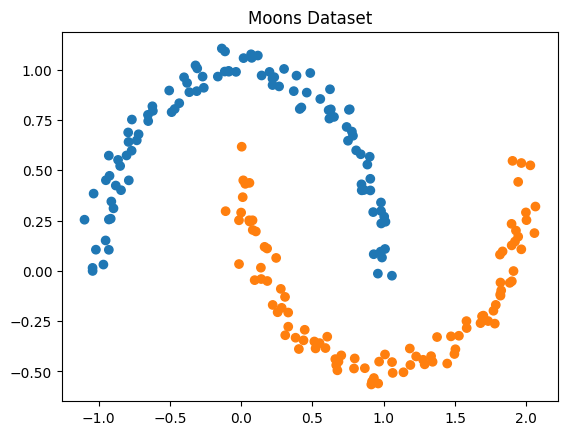

In [24]:
X_moons, y_moons = make_moons(n_samples=200, noise=.05, random_state=42)
y_moons = np.where(y_moons <= 0, -1, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1],
            c=y_moons, cmap=colors.ListedColormap(clrs))
plt.title('Moons Dataset')
plt.show()

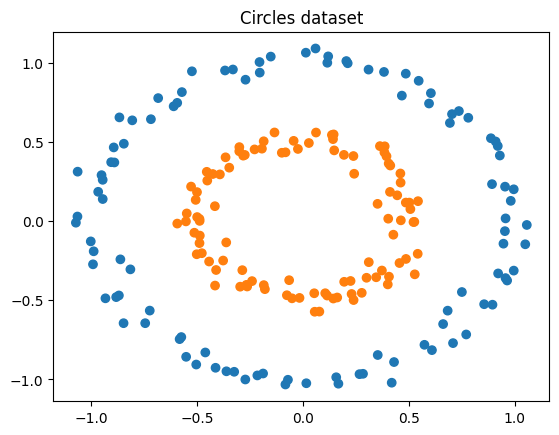

In [25]:
X_circles, y_circles = make_circles(n_samples=200, factor=.5, noise=.05, random_state=42)
y_circles = np.where(y_circles <= 0, -1, 1)
plt.scatter(X_circles[:, 0], X_circles[:, 1],
            c=y_circles, cmap=colors.ListedColormap(clrs))
plt.title('Circles dataset')
plt.show()

Напишем класс KernelSVM.

In [26]:
class KernelSVM:

  def __init__(self, C=3, kernel='poly', degree=4, gamma=None, coef=2):
    self.C = C
    self.kernel = kernel
    self.degree = degree
    self.gamma = gamma
    self.coef = coef
    self.lagr_multipliers = None
    self.support_vectors = None
    self.support_vector_labels = None
    self.intercept = None

  def _kernel(self, x1, x2):
    if self.kernel == 'linear':
      return np.dot(x1, x2)
    elif self.kernel == 'poly':
      return (self.gamma * np.dot(x1, x2) + self.coef) ** self.degree
    elif self.kernel == 'rbf':
      return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)

  def fit(self, X, y):
    n_samples, n_features = np.shape(X)
    if self.gamma is None:
      self.gamma = 1 / n_features

    K = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(n_samples):
        K[i, j] = self._kernel(X[i], X[j])

    P = cvxopt.matrix(np.outer(y, y) * K, tc='d')
    q = cvxopt.matrix(np.ones(n_samples) * -1)
    A = cvxopt.matrix(y, (1, n_samples), tc='d')
    b = cvxopt.matrix(0.0)

    if not self.C:
      G = cvxopt.matrix(np.identity(n_samples) * -1)
      h = cvxopt.matrix(np.zeros(n_samples))
    else:
      G_max = np.identity(n_samples) * -1
      G_min = np.identity(n_samples)
      G = cvxopt.matrix(np.vstack((G_max, G_min)))
      h_max = cvxopt.matrix(np.zeros(n_samples))
      h_min = cvxopt.matrix(np.ones(n_samples) * self.C)
      h = cvxopt.matrix(np.vstack((h_max, h_min)))

    solution = cvxopt.solvers.qp(P, q, G, h, A, b)

    alphas = np.ravel(solution['x'])

    idx = alphas > 1e-5
    self.support_alphas = alphas[idx]
    self.support_vectors = X[idx]
    self.support_vector_labels = y[idx]

    # рассчитаем b на основе первого опорного вектора self.support_vectors[0]
    temp_sum = 0
    for i in range(len(self.support_alphas)):
      temp_sum += self.support_alphas[i] * self.support_vector_labels[
          i] * self._kernel(self.support_vectors[i], self.support_vectors[0])
    self.intercept = self.support_vector_labels[0] - temp_sum

    return self

  def predict(self, X):
    scores, y_pred = [], []
    for sample in X:
      prediction = 0
      for i in range(len(self.support_alphas)):
        prediction += self.support_alphas[i] * self.support_vector_labels[
            i] * self._kernel(self.support_vectors[i], sample)
      prediction += self.intercept

      scores.append(prediction)
      y_pred.append(np.sign(prediction))

    return np.array(y_pred), np.array(scores)

Применим полиномиальное ядро степени три к набору данных moons.

In [27]:
poly_kernel_model = KernelSVM(kernel='poly', degree=3).fit(X_moons, y_moons)

In [28]:
accuracy_score(y_moons, poly_kernel_model.predict(X_moons)[0])

1.0

Посмотрим на разделяющую границу на графике.

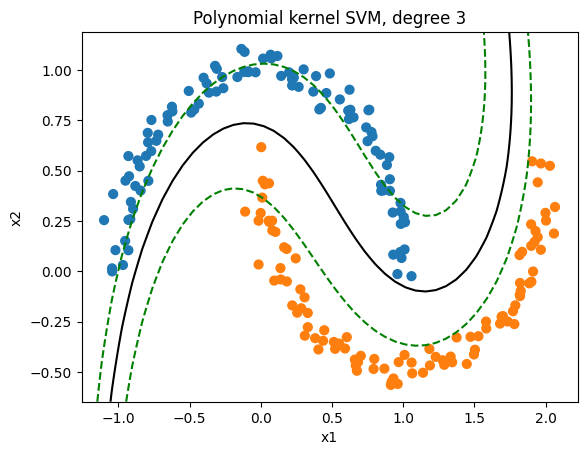

In [29]:
plt.scatter(X_moons[:, 0], X_moons[:, 1],
            c=y_moons, s=40, cmap=colors.ListedColormap(clrs))
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
# найдем нелинейную разделяющую границу
Z = poly_kernel_model.predict(xy)[1].reshape(XX.shape)
ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['g','k','g'], linestyles=['--', '-', '--'])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Polynomial kernel SVM, degree 3')
plt.show()

Поясним, что линейной границе в $\mathcal{H}$ соответствует нелинейная граница
в $\mathcal{L}.$

Теперь применим ядро радиальной базисной функции к датасету circles.

In [30]:
rbf_kernel_model = KernelSVM(kernel='rbf').fit(X_circles, y_circles)

In [31]:
accuracy_score(y_circles, rbf_kernel_model.predict(X_circles)[0])

1.0

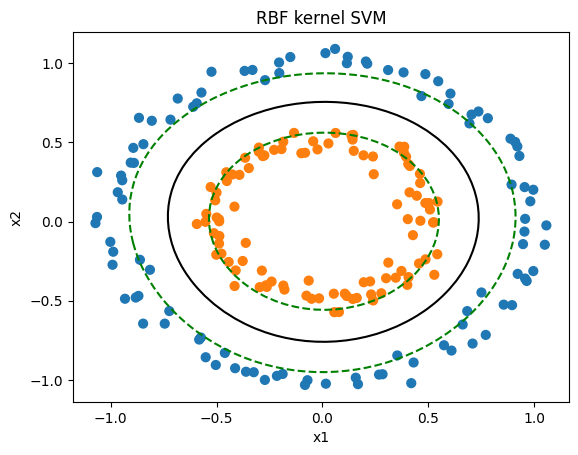

In [32]:
plt.scatter(X_circles[:, 0], X_circles[:, 1],
            c=y_circles, s=40, cmap=colors.ListedColormap(clrs))
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = rbf_kernel_model.predict(xy)[1].reshape(XX.shape)
ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['g','k','g'], linestyles=['--', '-', '--'])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('RBF kernel SVM')
plt.show()

## Список литературы
* Christopher J.C. Burges, A Tutorial on Support Vector Machines for Pattern
Recognition (https://www.di.ens.fr/~mallat/papiers/svmtutorial.pdf 0
* Chuong B. Do, Convex Optimization Overview (https://cs229.stanford.edu/section/cs229-cvxopt2.pdf)
* Andrew Ng, CS229 Lecture notes. Part V. SVM (https://see.stanford.edu/materials/aimlcs229/cs229-notes3.pdf)
* Воронцов К.В., Лекции по методу опорных векторов (http://www.ccas.ru/voron/download/SVM.pdf)
* Shawe-Taylor J., Cristianini N., Kernel Methods for Pattern Analysis, Cambridge
University Press, 2004